In [1]:
#PHASE 1 – Dataset Loading 
#Step 2 – Define Dataset Paths

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os

In [2]:
#Step 2 – Define Dataset Paths

train_dir = r"C:\Users\GAMYA\OneDrive\Desktop\PDT\Training"
test_dir  = r"C:\Users\GAMYA\OneDrive\Desktop\PDT\Testing"

In [3]:
#Step 3 – Load Training Dataset

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'  
)

#Step 4 – Load Testing Dataset

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [4]:
#Step 5 – Check Class Names

class_names = train_dataset.class_names
print("Classes:", class_names)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
#Step 6 – Check Dataset Shape

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32, 4)


In [6]:
#Phase 2 – Preprocessing (Normalization + Optimization + Prefetching)
#Step 1 – Normalize Images

def normalize(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Min pixel value:", tf.reduce_min(images).numpy())
    print("Max pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 128, 128, 3)
Min pixel value: 0.0
Max pixel value: 1.0


In [7]:
#Step 2 – Convert to Grayscale

def to_grayscale(images, labels):
    images = tf.image.rgb_to_grayscale(images)
    return images, labels

train_dataset = train_dataset.map(to_grayscale)
test_dataset = test_dataset.map(to_grayscale)

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)

Image batch shape: (32, 128, 128, 1)


In [8]:
#Step 3 – Optimize Dataset Performance

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
#Step 4 – Verify Shape After Preprocessing

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 128, 128, 1)
Label batch shape: (32, 4)


In [10]:
#PHASE 3 – AUTOENCODER (Feature Learning)

autoencoder_train = train_dataset.map(lambda x, y: (x, x))
autoencoder_test = test_dataset.map(lambda x, y: (x, x))

In [ ]:
#STEP 2 – Build Autoencoder Architecture

from tensorflow.keras import layers, models

input_shape = (128, 128, 1)


inputs = layers.Input(shape=input_shape)

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)


x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(inputs, decoded)

In [12]:
#STEP 3 – Compile Model

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [21]:
#STEP 4 – Train Autoencoder

history = autoencoder.fit(
    autoencoder_train,
    validation_data=autoencoder_test,
    epochs=15
)


Epoch 1/15

175/175 [==============================] - 134s 739ms/step - loss: 0.3911 - val_loss: 0.3685
Epoch 2/15
175/175 [==============================] - 126s 721ms/step - loss: 0.3570 - val_loss: 0.3630
Epoch 3/15
175/175 [==============================] - 121s 691ms/step - loss: 0.3527 - val_loss: 0.3615
Epoch 4/15
175/175 [==============================] - 133s 762ms/step - loss: 0.3510 - val_loss: 0.3586
Epoch 5/15
175/175 [==============================] - 158s 905ms/step - loss: 0.3497 - val_loss: 0.3582
Epoch 6/15
175/175 [==============================] - 158s 906ms/step - loss: 0.3492 - val_loss: 0.3572
Epoch 7/15
175/175 [==============================] - 156s 891ms/step - loss: 0.3485 - val_loss: 0.3565
Epoch 8/15
175/175 [==============================] - 234s 1s/step - loss: 0.3482 - val_loss: 0.3563
Epoch 9/15
175/175 [==============================] - 125s 713ms/step - loss: 0.3477 - val_loss: 0.3568
Epoch 10/15
175/175 [==============================] - 125s 712ms/

In [22]:
encoder = tf.keras.Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer(index=6).output
)

# STEP 6 – Save both
encoder.save("encoder_model.h5")
autoencoder.save("autoencoder_model.h5")

----- AUTOENCODER OUTPUT -----
1/1 [==============================] - 0s 235ms/step
Input Shape: (32, 128, 128, 1)
Encoded Shape: (32, 16, 16, 128)
Reconstructed Shape: (32, 128, 128, 1)


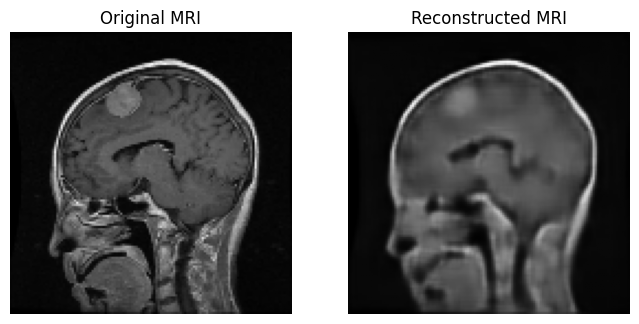

In [23]:
print("----- AUTOENCODER OUTPUT -----")

for images, labels in train_dataset.take(1):
    
    # Reconstructed images
    reconstructed = autoencoder.predict(images)
    
    # Encoded (latent representation)
    encoded = encoder.predict(images)
    
    print("Input Shape:", images.shape)
    print("Encoded Shape:", encoded.shape)
    print("Reconstructed Shape:", reconstructed.shape)
    
    # Show first image comparison
    import matplotlib.pyplot as plt
    
    original = images[0].numpy().squeeze()
    recon = reconstructed[0].squeeze()
    
    plt.figure(figsize=(8,4))
    
    plt.subplot(1,2,1)
    plt.imshow(original, cmap="gray")
    plt.title("Original MRI")
    plt.axis("off")
    
    plt.subplot(1,2,2)
    plt.imshow(recon, cmap="gray")
    plt.title("Reconstructed MRI")
    plt.axis("off")
    
    plt.show()
    
    break

In [24]:
#STEP 5 – Extract Encoder Only

encoder.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 32, 32, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       7385

In [25]:
#PHASE 4 – HYBRID CNN CLASSIFIER (Fine-Tuning Encoder)
#STEP 1 –  Encoder is Trainable

encoder.trainable = True

In [26]:
#STEP 2 – Build Hybrid Model (Encoder + CNN Head)

from tensorflow.keras import layers, models

# Input layer
inputs = layers.Input(shape=(128,128,1))

# Pass through trained encoder
encoded_features = encoder(inputs)

# ----- Classification Head -----

x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(encoded_features)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Flatten()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(4, activation='softmax')(x)

# Final Hybrid Model
hybrid_model = models.Model(inputs, outputs)

In [27]:
#STEP 3 – Compile Model

hybrid_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
#STEP 4 – Train Model

history = hybrid_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=15
)


Epoch 1/15



175/175 [==============================] - 72s 395ms/step - loss: 0.7253 - accuracy: 0.7171 - val_loss: 0.8466 - val_accuracy: 0.7131
Epoch 2/15
175/175 [==============================] - 68s 390ms/step - loss: 0.3572 - accuracy: 0.8704 - val_loss: 0.7398 - val_accuracy: 0.8069
Epoch 3/15
175/175 [==============================] - 68s 390ms/step - loss: 0.2503 - accuracy: 0.9062 - val_loss: 0.5741 - val_accuracy: 0.8194
Epoch 4/15
175/175 [==============================] - 69s 393ms/step - loss: 0.1757 - accuracy: 0.9377 - val_loss: 0.6287 - val_accuracy: 0.8737
Epoch 5/15
175/175 [==============================] - 68s 392ms/step - loss: 0.1228 - accuracy: 0.9546 - val_loss: 0.6824 - val_accuracy: 0.8813
Epoch 6/15
175/175 [==============================] - 68s 391ms/step - loss: 0.1019 - accuracy: 0.9661 - val_loss: 0.6650 - val_accuracy: 0.9038
Epoch 7/15
175/175 [==============================] - 68s 388ms/step - loss: 0.0530 - accuracy: 0.9814 - val_loss: 1.0452 - val_accuracy: 0.

In [19]:
hybrid_model.save("hybrid_brain_tumor_model.h5")

In [20]:
import numpy as np

for images, labels in test_dataset.take(1):
    predictions = hybrid_model.predict(images)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    
    print("Predicted Class:", class_names[predicted_class])
    print("Confidence: {:.2f}%".format(confidence * 100))

1/1 [==============================] - 1s 548ms/step
Predicted Class: pituitary
Confidence: 25.03%


1/1 [==============================] - 0s 279ms/step


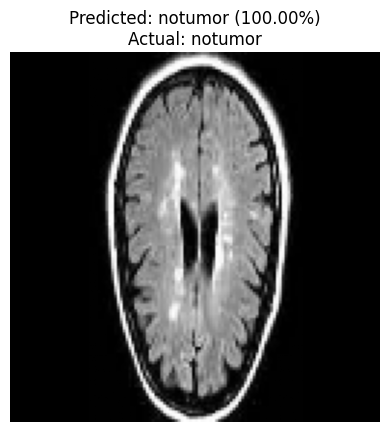

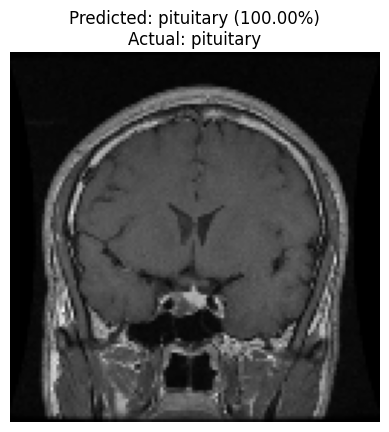

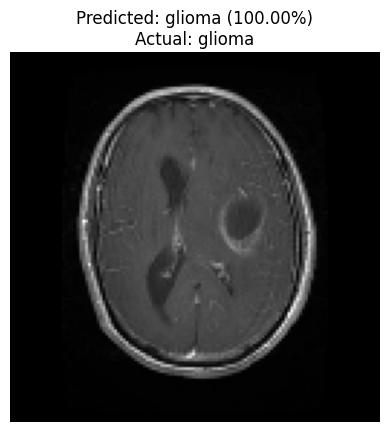

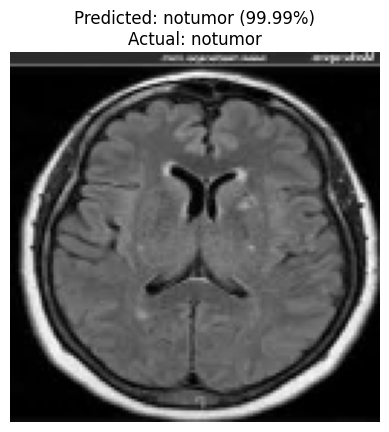

In [30]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in test_dataset.take(1):
    predictions = hybrid_model.predict(images)

    for i in range(4):  
        predicted_class = np.argmax(predictions[i])
        confidence = np.max(predictions[i])
        true_class = np.argmax(labels[i])

        plt.figure()
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(
            f"Predicted: {class_names[predicted_class]} ({confidence*100:.2f}%)\n"
            f"Actual: {class_names[true_class]}"
        )
        plt.axis("off")
        plt.show()

In [31]:
#PHASE 5 – Grad-CAM (Tumor Localization)

for layer in hybrid_model.layers:
    print(layer.name, layer.output_shape)

input_3 [(None, 128, 128, 1)]
model_3 (None, 16, 16, 128)
conv2d_9 (None, 16, 16, 128)
max_pooling2d_5 (None, 8, 8, 128)
conv2d_10 (None, 8, 8, 256)
max_pooling2d_6 (None, 4, 4, 256)
flatten_1 (None, 4096)
dense_2 (None, 256)
dropout_1 (None, 256)
dense_3 (None, 4)


In [32]:
#Step 1 – Grad-CAM Function

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    
    # Create a model that maps input image to:
    # (1) Last conv layer output
    # (2) Final predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Record gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    # Compute gradients of top predicted class
    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel by its importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

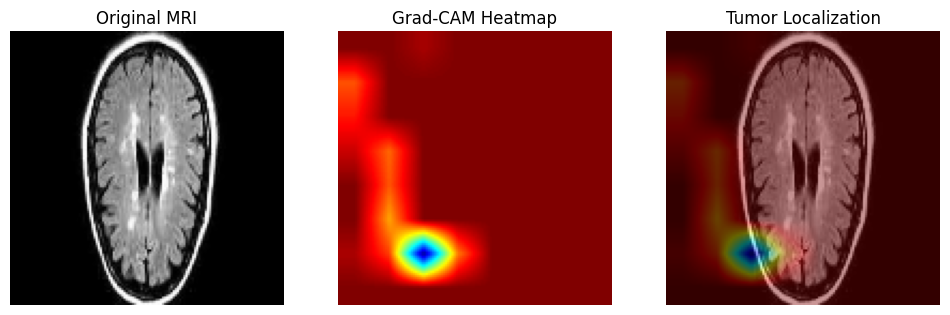

In [34]:
for images, labels in test_dataset.take(1):

    img = images[0:1]

    # Generate heatmap (0–1 scale)
    heatmap = make_gradcam_heatmap(img, hybrid_model, "conv2d_10")

    # Resize but DO NOT convert yet
    heatmap_resized = cv2.resize(heatmap, (128, 128))

    # Create display version (for visualization only)
    heatmap_display = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_display, cv2.COLORMAP_JET)

    original_img = images[0].numpy().squeeze()
    original_img = np.uint8(original_img * 255)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_GRAY2RGB)

    superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original MRI")
    plt.imshow(original_img)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(heatmap_color)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Tumor Localization")
    plt.imshow(superimposed_img)
    plt.axis("off")

    plt.show()

In [35]:
#PHASE 6 – Pseudo Segmentation (Tumor Mask Extraction)
#Step 1 – Convert Heatmap to Binary Mask

# Normalize heatmap (0 to 1 already done earlier)
threshold = 0.65  # you can adjust (0.4–0.6 works well)

binary_mask = (heatmap_resized > threshold).astype(np.uint8)
binary_mask = binary_mask.astype(np.uint8)

In [36]:
#Step 2 – Resize Mask to Image Size
binary_mask = cv2.resize(binary_mask, (128, 128))

In [37]:
#Step 3 – Extract Tumor Region from Original Image
segmented = original_img.copy()
segmented[binary_mask == 0] = 0

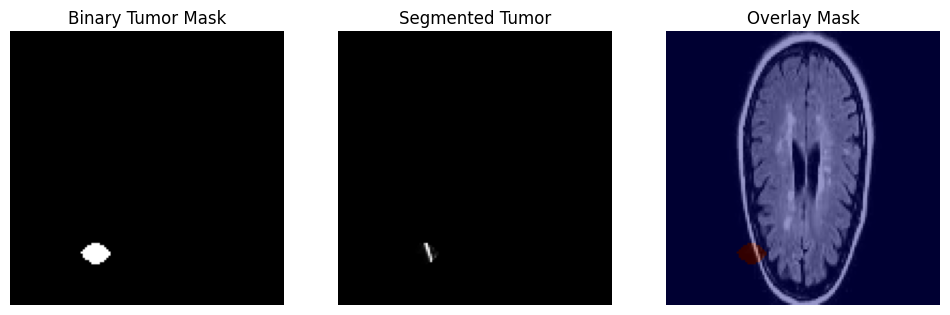

In [38]:
#Step 4 – Display Segmentation

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Binary Tumor Mask")
plt.imshow(binary_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Segmented Tumor")
plt.imshow(segmented)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay Mask")
plt.imshow(original_img)
plt.imshow(binary_mask, cmap='jet', alpha=0.4)
plt.axis("off")

plt.show()

In [39]:
#PHASE 7 – Severity Analysis (Tumor Area Calculation)
#Step 1 – Calculate Tumor Area %

# Count tumor pixels
tumor_pixels = np.sum(binary_mask)

# Total pixels in brain image
total_pixels = binary_mask.shape[0] * binary_mask.shape[1]

# Calculate percentage
tumor_percentage = (tumor_pixels / total_pixels) * 100

print("Tumor Area Percentage: {:.2f}%".format(tumor_percentage))

Tumor Area Percentage: 0.57%


In [40]:
# Step 2 – Severity Classification

if tumor_percentage < 5:
    severity = "Mild"
elif tumor_percentage < 15:
    severity = "Moderate"
else:
    severity = "Severe"

print("Severity Level:", severity)

Severity Level: Mild


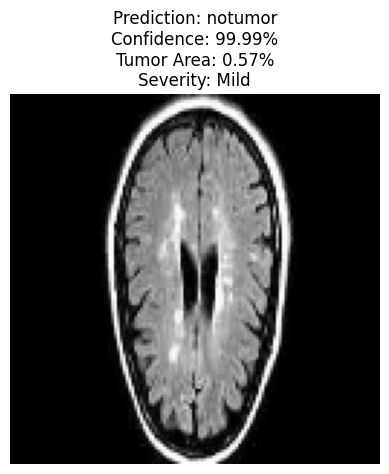

In [41]:
plt.figure()
plt.imshow(original_img)
plt.title(
    f"Prediction: {class_names[predicted_class]}\n"
    f"Confidence: {confidence*100:.2f}%\n"
    f"Tumor Area: {tumor_percentage:.2f}%\n"
    f"Severity: {severity}"
)
plt.axis("off")
plt.show()

In [42]:
#PHASE 8 – Performance Evaluation
#Step 1 – Get All Predictions on Test Set

import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = hybrid_model.predict(images)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 [==============================] - 0s 165ms/step


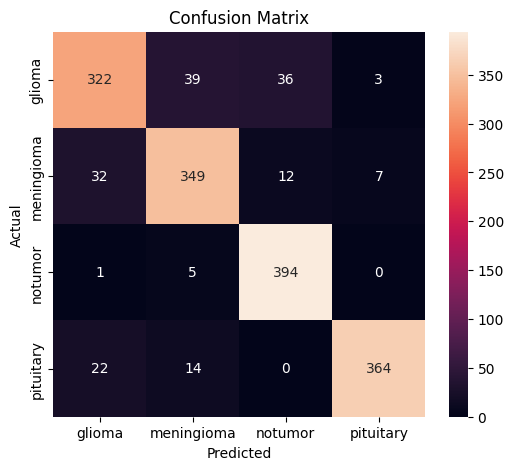

In [43]:
#Step 2 – Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
#Step 3 – Classification Report
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

      glioma       0.85      0.81      0.83       400
  meningioma       0.86      0.87      0.86       400
     notumor       0.89      0.98      0.94       400
   pituitary       0.97      0.91      0.94       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def analyze_mri(image_path, model, class_names):

    original = cv2.imread(image_path)
    if original is None:
        print("Error loading image.")
        return

    # ===== MODEL PREPROCESS =====
    img = cv2.resize(original, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255.0
    img = np.reshape(img, (1, 128, 128, 1))

    # ===== Prediction =====
    prediction = model.predict(img, verbose=0)[0]
    class_index = np.argmax(prediction)
    confidence = float(prediction[class_index]) * 100
    predicted_class = class_names[class_index]

    # ===== Tumor Area (same method) =====
    if predicted_class == "notumor":
        tumor_area_percentage = 0.0
        severity = "No Tumor Detected"

    else:
        gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(
            gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        tumor_pixels = np.sum(thresh == 255)
        total_pixels = thresh.size
        tumor_area_percentage = (tumor_pixels / total_pixels) * 100

        # ===== CLASS-AWARE SEVERITY =====
        if predicted_class == "pituitary":
            mild_t, mod_t = 3, 10

        elif predicted_class == "glioma":
            mild_t, mod_t = 8, 20

        elif predicted_class == "meningioma":
            mild_t, mod_t = 15, 30

        else:
            mild_t, mod_t = 5, 15

        if confidence < 85:
            severity = "Mild"
        elif tumor_area_percentage < mild_t:
            severity = "Mild"
        elif tumor_area_percentage < mod_t:
            severity = "Moderate"
        else:
            severity = "Severe"

    # ===== DISPLAY =====
    fig = plt.figure(figsize=(10, 5))
    ax_text = plt.axes([0.05, 0.15, 0.4, 0.7])
    ax_text.axis("off")

    ax_text.text(
        0, 0.8,
        f"Prediction : {predicted_class}\n\n"
        f"Confidence : {confidence:.2f}%\n\n"
        f"Tumor Area : {tumor_area_percentage:.2f}%\n\n"
        f"Severity   : {severity}",
        fontsize=16,
        verticalalignment="top"
    )

    ax_img = plt.axes([0.5, 0.15, 0.45, 0.7])
    ax_img.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    ax_img.axis("off")

    plt.show()

    return predicted_class, confidence, tumor_area_percentage, severity

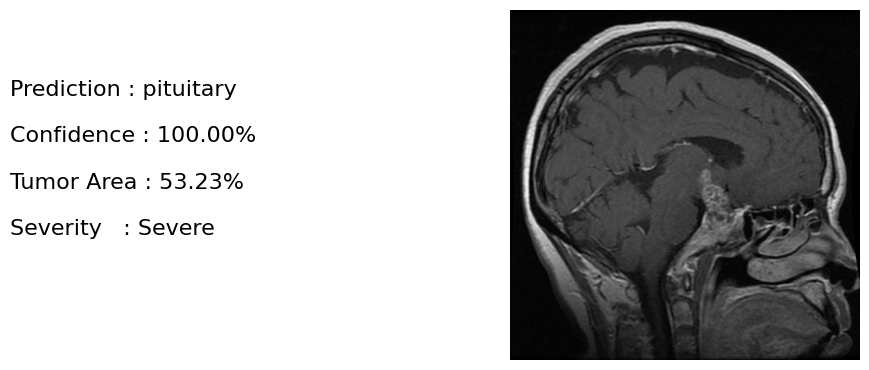

('pituitary', 99.99992847442627, 53.2257080078125, 'Severe')

In [46]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

analyze_mri(
    r"C:\Users\GAMYA\OneDrive\Desktop\PDT\Testing\pituitary\Te-pi_100.jpg",
    hybrid_model,
    class_names
)

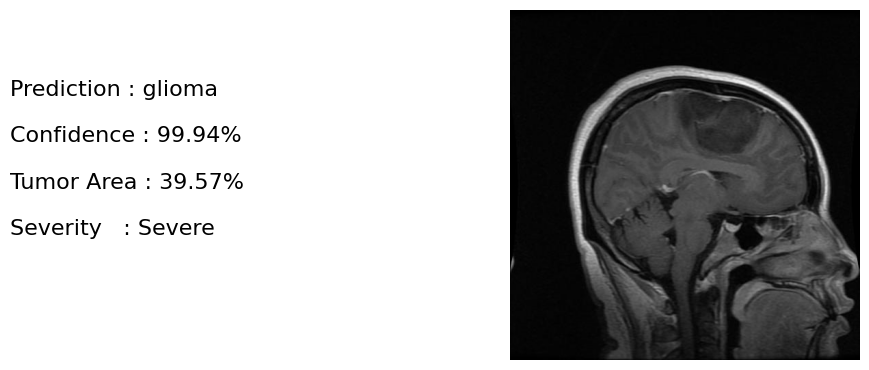

('glioma', 99.93797540664673, 39.57099914550781, 'Severe')

In [47]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

analyze_mri(
    r"C:\Users\GAMYA\OneDrive\Desktop\PDT\Testing\glioma\Te-gl_56.jpg",
    hybrid_model,
    class_names
)

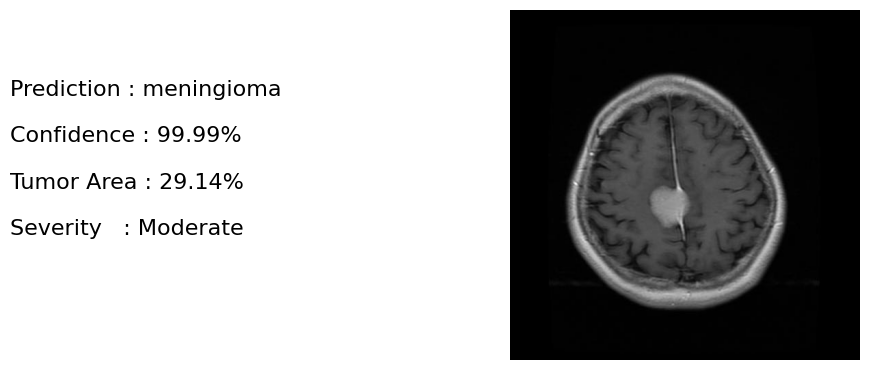

('meningioma', 99.99239444732666, 29.140472412109375, 'Moderate')

In [48]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

analyze_mri(
    r"C:\Users\GAMYA\OneDrive\Desktop\PDT\Testing\meningioma\Te-me_294.jpg",
    hybrid_model,
    class_names
)

Random Image Selected: C:\Users\GAMYA\OneDrive\Desktop\PDT\Testing\notumor\Te-no_359.jpg


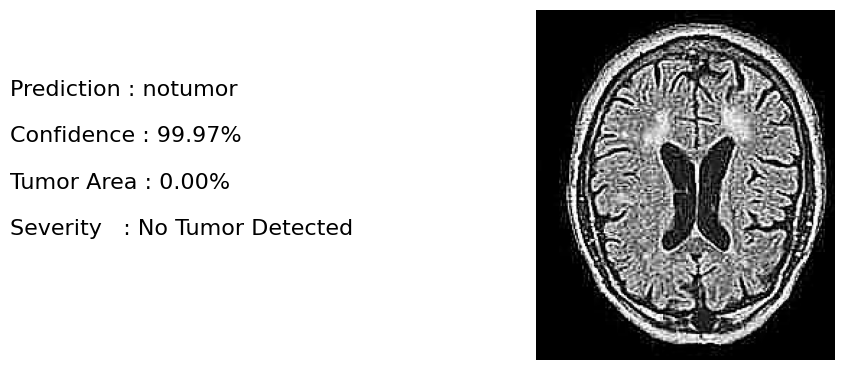

('notumor', 99.97385144233704, 0.0, 'No Tumor Detected')

In [54]:
import os
import random

# Path to your testing dataset folder
test_root_dir = r"C:\Users\GAMYA\OneDrive\Desktop\PDT\Testing"

# List all class folders
class_folders = [os.path.join(test_root_dir, cls) for cls in os.listdir(test_root_dir)
                 if os.path.isdir(os.path.join(test_root_dir, cls))]

# Pick a random class folder
random_class_folder = random.choice(class_folders)

# List all images in that folder
images_in_folder = [os.path.join(random_class_folder, img) for img in os.listdir(random_class_folder)
                    if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Pick a random image
random_image_path = random.choice(images_in_folder)

print("Random Image Selected:", random_image_path)

# Run your analyze_mri function
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
analyze_mri(random_image_path, hybrid_model, class_names)